In [46]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import solve_ivp
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
from torch.optim import lr_scheduler
import numpy as np
import time
import matplotlib
from matplotlib import pyplot as pp
import scipy
from scipy.integrate import solve_ivp
import random
import functools
import pickle

import pandas as pd
import functools
from scipy.optimize import curve_fit

Get Ground truth data no noise and sparcity

dict_keys(['data_groundtruth', 'data_sampled', 'data_sampled_random', 'data_sampled_random_with_noise', 'data_colloc'])
dict_keys(['ground_truth_params', 'model: No external force', 'model: sinusoidal force', 'model: square wave force', 'model: reference tracking with P controller'])
dict_keys(['x0', 't_span', 't_eval', 'm_true', 'c_true', 'k_true', 'Kp_array', 'delta_val', 'omega0_val', 'T_val'])
[1.0, 0.0]
dict_keys(['t', 'x', 'v'])


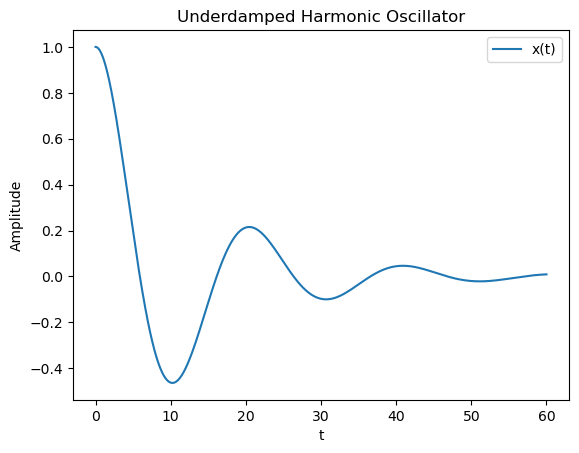

In [47]:
# Load the pickle file into a DataFrame



file_path = '/Users/abhi/Desktop/Projects/Sys_ID/Untitled/PINN-tutorial/data/massdamper_data.pkl'

with open(file_path, 'rb') as file:
    data = pickle.load(file)

# Check if it's a dictionary, then print keys
if isinstance(data, dict):
    print(data.keys())
else:
    print("Data is not a dictionary. Type is:", type(data))

#get ground truth data
ground_truth_data = data['data_groundtruth']

print(ground_truth_data.keys())

#get parameters for ground truth data such as x0, v0, t, omega0, and delta
#get the displacement and time data from the no external force model
ground_truth_parameters = ground_truth_data['ground_truth_params']
no_external_force_model = ground_truth_data['model: No external force']

print(ground_truth_parameters.keys())

#map parameters to corresponding variables
ordered_keys = ground_truth_parameters.keys()

(x0, t_span, t_eval, m_true, c_true, k_true, Kp_array, delta_val, omega0_val, T_val) = [ground_truth_parameters[k] for k in ordered_keys]


print(x0)
print(no_external_force_model.keys())

#print(ground_truth_parameters.items())

#get time, velocity, position data from unforced model
t = no_external_force_model['t']
x = no_external_force_model['x']
v = no_external_force_model['v']

times = t
yexact2 = x

#plot our time displacement response
plt.plot(times, yexact2,label="x(t)")
plt.xlabel("t")
plt.ylabel("Amplitude")
plt.title("Underdamped Harmonic Oscillator")
plt.legend()
plt.show()
#print(f"time: {t}")
#print(f"x {x}")
#print(f"v {v}")

Get frequency response function using dft

0.06006006006006006
xf: [0.      0.01665 0.0333  0.04995 0.0666  0.08325 0.0999  0.11655 0.1332
 0.14985 0.1665  0.18315 0.1998  0.21645 0.2331  0.24975 0.2664  0.28305
 0.2997  0.31635 0.333   0.34965 0.3663  0.38295 0.3996  0.41625 0.4329
 0.44955 0.4662  0.48285 0.4995  0.51615 0.5328  0.54945 0.5661  0.58275
 0.5994  0.61605 0.6327  0.64935 0.666   0.68265 0.6993  0.71595 0.7326
 0.74925 0.7659  0.78255 0.7992  0.81585 0.8325  0.84915 0.8658  0.88245
 0.8991  0.91575 0.9324  0.94905 0.9657  0.98235 0.999   1.01565 1.0323
 1.04895 1.0656  1.08225 1.0989  1.11555 1.1322  1.14885 1.1655  1.18215
 1.1988  1.21545 1.2321  1.24875 1.2654  1.28205 1.2987  1.31535 1.332
 1.34865 1.3653  1.38195 1.3986  1.41525 1.4319  1.44855 1.4652  1.48185
 1.4985  1.51515 1.5318  1.54845 1.5651  1.58175 1.5984  1.61505 1.6317
 1.64835 1.665   1.68165 1.6983  1.71495 1.7316  1.74825 1.7649  1.78155
 1.7982  1.81485 1.8315  1.84815 1.8648  1.88145 1.8981  1.91475 1.9314
 1.94805 1.9647  1.98135 1.998   2.

No handles with labels found to put in legend.


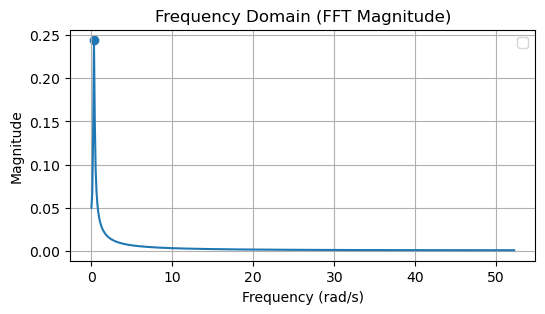

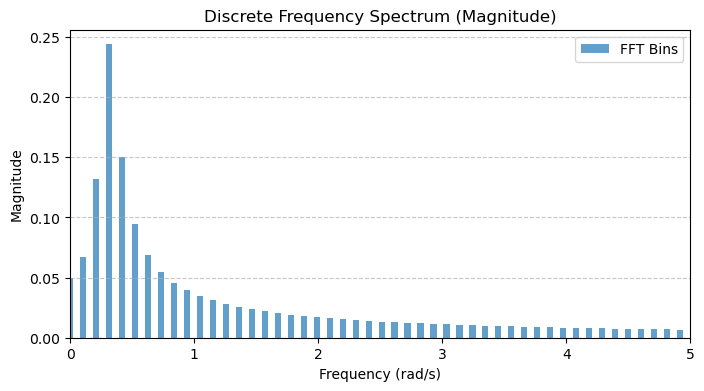

actual wn 0.31622776601683794


In [48]:
#Cool Now lets get into the actual system identification

def get_frf(yexact2, times):
    N = len(yexact2)
    dt = times[1] - times[0]  # Sampling interval
    print(dt)
    yf = np.fft.fft(yexact2)
    xf = np.fft.fftfreq(N, dt)[:N//2] # Get positive frequencies
    print(f"xf: {xf}")

    # 2. Get Magnitude (Power Spectrum)
    magnitude = 2.0/N * np.abs(yf[0:N//2])

    # 2. Get Magnitude (Power Spectrum)
    magnitude = 2.0/N * np.abs(yf[0:N//2])

   
    


    return xf, magnitude

xf, magnitude = get_frf(yexact2, times)

# 3. Find the peak frequency (Experimental wd) 
peak_index = np.argmax(magnitude)
print(peak_index)
wd_experimental = xf[peak_index] * 2 * np.pi # Convert Hz to rad/s
print(f"Experimental Damped Frequency (wd): {wd_experimental} rad/s")

xf_rad = 2* np.pi * xf


plt.figure(figsize=(6,3))
plt.plot(xf * 2 * np.pi, magnitude)
#plt.axvline(wd_experimental, color='r', linestyle='--', label=f'Peak at {wd_experimental:.2f} rad/s')
plt.scatter(wd_experimental, magnitude[peak_index])
plt.title("Frequency Domain (FFT Magnitude)")
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))

# Using bar to show the 'bins'
plt.bar(xf * 2 * np.pi, magnitude, width=0.05, color='tab:blue', alpha=0.7, label='FFT Bins')

# Optional: Add a stem plot on top for clarity
#plt.stem(xf * 2 * np.pi, magnitude, linefmt='r-', markerfmt='ro', basefmt=" ", label='Discrete Frequencies')

plt.title("Discrete Frequency Spectrum (Magnitude)")
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Magnitude")
plt.xlim(0, 5) # Zooming in on the area of interest (near omega0=20)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"actual wn {omega0_val}")

Nonlinear regression least squares fitting function

In [49]:
#initial_conditions = x0
def response_magnitude(w, wn, zeta, A):
    """
    Generalized Frequency Response Function Magnitude.
    Works for all damping regimes.
    """
    r = w / wn
    denominator = np.sqrt((1 - r**2)**2 + (2 * zeta * r)**2)
    theoretical = A / denominator
    return theoretical

Applying least squares regression to frf

In [50]:
mask = (xf_rad > 0) & (xf_rad < 5) # only choosing frequencies between 0 and 5 where the max response magnitude is


w_data = xf_rad[mask]
mag_data = magnitude[mask]
#print(w_data)
#print(mag_data)




# Example of how to run the fit:
# p0: Initial guesses [wn, zeta, A]
# bounds: (lower_limits, upper_limits) 
# This prevents wn and zeta from going negative or zero
popt, pcov = curve_fit(
    response_magnitude, 
    w_data, 
    mag_data, 
    p0=[0.22, 0.19, 1.0], 
    bounds=((0.001, 0.001, 0.001), (np.inf, np.inf, np.inf))
)

wn_fit, zeta_fit, A_fit = popt
print(f"Fit Results: wn={wn_fit:.2f}, zeta={zeta_fit:.2f}, Gain={A_fit:.2f}")

#wn_fit, zeta_fit = popt

zeta_actual = delta_val / omega0_val
wn_actual = omega0_val
print(f"Approximated wn: {wn_fit} rad/s")
print(f"actual wn: {wn_actual} rad/s")
print(f"Approximated zeta: {zeta_fit}")
print(f"actual zeta: {zeta_actual}")

m_est = 1.0
k_est = m_est * (wn_fit**2) #really finding k/m
k_actual = m_est * (wn_actual**2)
c_est = 2 * zeta_fit * wn_fit * m_est #really finding c/m
c_actual = 2 * zeta_actual * wn_actual * m_est

print(f"Calculated Parameters: k={k_est}, c={c_est}")
print(f"Actual Parameters: k={k_actual}, c={c_actual}, m={m_true}")

Fit Results: wn=0.36, zeta=0.20, Gain=0.10
Approximated wn: 0.3606929033494289 rad/s
actual wn: 0.31622776601683794 rad/s
Approximated zeta: 0.19667251030593175
actual zeta: 0.23717082451262844
Calculated Parameters: k=0.13009937052664045, c=0.14187675750253398
Actual Parameters: k=0.1, c=0.15, m=2


Get Metrics for different frequency ranges(0,1) -->> (0,10)


[0.4, 0.5, 0.6, 0.7, 0.7999999999999999, 0.8999999999999999, 0.9999999999999999, 1.0999999999999999, 1.1999999999999997, 1.2999999999999998, 1.4, 1.4999999999999996, 1.5999999999999996, 1.6999999999999997, 1.7999999999999998, 1.8999999999999995, 1.9999999999999996, 2.0999999999999996, 2.1999999999999997, 2.2999999999999994, 2.3999999999999995, 2.4999999999999996, 2.599999999999999, 2.6999999999999993, 2.7999999999999994, 2.8999999999999995, 2.9999999999999996, 3.099999999999999, 3.1999999999999993, 3.2999999999999994, 3.399999999999999, 3.499999999999999, 3.599999999999999, 3.6999999999999993, 3.7999999999999994, 3.899999999999999, 3.999999999999999, 4.1, 4.199999999999999, 4.299999999999999, 4.3999999999999995, 4.499999999999999, 4.6, 4.699999999999999, 4.799999999999999, 4.8999999999999995]


/Users/abhi/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


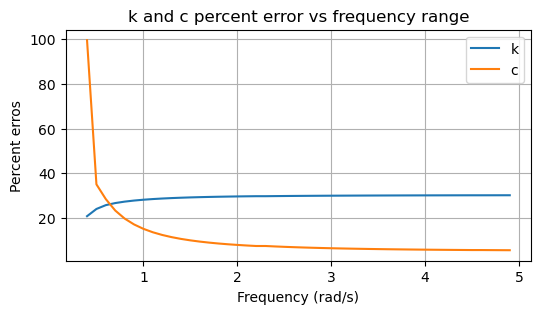

In [51]:
k_percent_errors = []
c_percent_error = []
frequency_range = np.arange(0.4, 5, 0.1).tolist()
print(frequency_range)

for i in range(0,len(frequency_range)):
    mask = (xf_rad > 0) & (xf_rad < frequency_range[i]) # only choosing frequencies between 0 and 5 where the max response magnitude is


    w_data = xf_rad[mask]
    mag_data = magnitude[mask]
    
    popt, pcov = curve_fit(
    response_magnitude, 
    w_data, 
    mag_data, 
    p0=[0.22, 0.19, 1.0], 
    bounds=((0.001, 0.001, 0.001), (np.inf, np.inf, np.inf))
)

    wn_fit, zeta_fit, A_fit = popt
    zeta_actual = delta_val / omega0_val
    wn_actual = omega0_val




    m_est = 1.0
    k_est = m_est * (wn_fit**2) #really finding k/m
    k_actual = m_est * (wn_actual**2)
    c_est = 2 * zeta_fit * wn_fit * m_est #really finding c/m
    c_actual = 2 * zeta_actual * wn_actual * m_est

    wn_percent_error_nff_nn_ns = abs(wn_fit - wn_actual) / wn_actual * 100
    zeta_percent_error_nff_nn_ns = abs(zeta_fit - zeta_actual) / zeta_actual * 100

    k_percent_error_nff_nn_ns = abs(k_est - k_actual) / k_actual * 100
    c_percent_error_nff_nn_ns = abs(c_est - c_actual) / c_actual * 100

    k_percent_errors.append(k_percent_error_nff_nn_ns)
    c_percent_error.append(c_percent_error_nff_nn_ns)

    

plt.figure(figsize=(6,3))
plt.plot(frequency_range, k_percent_errors, label="k")
plt.plot(frequency_range, c_percent_error, label = "c")

plt.title("k and c percent error vs frequency range")
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Percent erros")
plt.legend()
plt.grid(True)
plt.show()





    

    

In [52]:
wn_percent_error_nff_nn_ns = abs(wn_fit - wn_actual) / wn_actual * 100
zeta_percent_error_nff_nn_ns = abs(zeta_fit - zeta_actual) / zeta_actual * 100

k_percent_error_nff_nn_ns = abs(k_est - k_actual) / k_actual * 100
c_percent_error_nff_nn_ns = abs(c_est - c_actual) / c_actual * 100

print(f"Percent error wn={wn_percent_error_nff_nn_ns}, zeta={zeta_percent_error_nff_nn_ns}")
print(f"Percent error k={k_percent_error_nff_nn_ns}, c={c_percent_error_nff_nn_ns}")

Percent error wn=14.058776475616847, zeta=17.09430156716629
Percent error k=30.094044911147282, c=5.438774738945218


#Lets do the same analysis for sinosoidal forcing function:

dict_keys(['t', 'x', 'v'])
data points: 1000


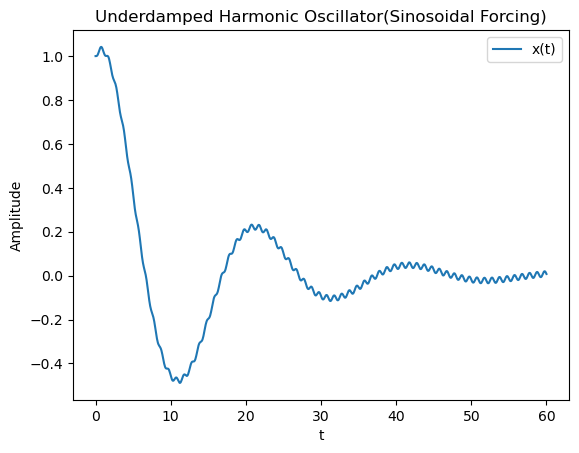

[0.0, 0.3684753948102499, 0.6850970904837809, 0.9053084995825966, 0.9981203720381463, 0.9504717573001115, 0.769068006574317, 0.47943716228880995, 0.12233752437845731, -0.2519780613851252, -0.5908340350059581, -0.8465448903300604, -0.9831257177957041, -0.9813561807535597, -0.8414852973000504, -0.5831963972062733, -0.24283718537858737, 0.13169528883562395, 0.48769494381363454, 0.7750637288796014, 0.9533616723774294, 0.9974977965944997, 0.9012610455459449, 0.6781943358146669, 0.35968872964453685, -0.009434072225895224, -0.37722926430276815, -0.6919388689775459, -0.9092753778138881, -0.9986541110764565, -0.9474972467204297, -0.7630038343715273, -0.47113670908301825, -0.11296887142907357, 0.2610965104120889, 0.5984190863909272, 0.8515291377333113, 0.984807753012208, 0.9794992993811166, 0.8363508089657767, 0.5755068527698898, 0.2336746959642524, -0.14104133192491902, -0.49590931868438887, -0.7809904676459168, -0.9561667347392505, -0.9967864401570344, -0.897133375942315, -0.6712312193409046, 

In [53]:
sinusoidal_force_model = ground_truth_data['model: sinusoidal force']


print(sinusoidal_force_model.keys())

u_2 = lambda t: np.sin(2 * np.pi * t)
t = sinusoidal_force_model['t']
x = sinusoidal_force_model['x']
v = sinusoidal_force_model['v']

times = t
yexact2 = x
print(f"data points: {len(t)}")

#plot our time displacement response
plt.plot(times, yexact2,label="x(t)")
plt.xlabel("t")
plt.ylabel("Amplitude")
plt.title("Underdamped Harmonic Oscillator(Sinosoidal Forcing)")
plt.legend()
plt.show()

force_u2 = []
for t in times:
    force_u2.append(u_2(t))

print(force_u2)
print(len(force_u2))
print(len(yexact2))




Get FRF of Sinosoidal Forcing msd

No handles with labels found to put in legend.


0.06006006006006006
magnitude: [4.84708253e+00 5.51499481e+00 2.43581453e+00 1.19497441e+00
 7.16498882e-01 4.81957543e-01 3.48159316e-01 2.63994324e-01
 2.07308488e-01 1.67135145e-01 1.37535250e-01 1.15078066e-01
 9.75761300e-02 8.36787205e-02 7.24501167e-02 6.32429375e-02
 5.55794551e-02 4.91649821e-02 4.37005555e-02 3.90326837e-02
 3.50075661e-02 3.14985910e-02 2.84265415e-02 2.57284083e-02
 2.33447310e-02 2.12333766e-02 1.93424333e-02 1.76515855e-02
 1.61246952e-02 1.47471773e-02 1.35006086e-02 1.23643880e-02
 1.13308924e-02 1.03849480e-02 9.51737147e-03 8.72595811e-03
 7.99282372e-03 7.31331333e-03 6.68262476e-03 6.09984082e-03
 5.55671380e-03 5.05258873e-03 4.58527275e-03 4.14666619e-03
 3.73566204e-03 3.35207235e-03 2.99377420e-03 2.65262273e-03
 2.33447466e-03 2.03432920e-03 1.75181416e-03 1.48565972e-03
 1.23452824e-03 9.98055520e-04 7.73843627e-04 5.61350372e-04
 3.59618225e-04 1.68051716e-04 1.46269854e-05 1.88891962e-04
 3.54285081e-04 5.11271299e-04 6.60547814e-04 8.030820

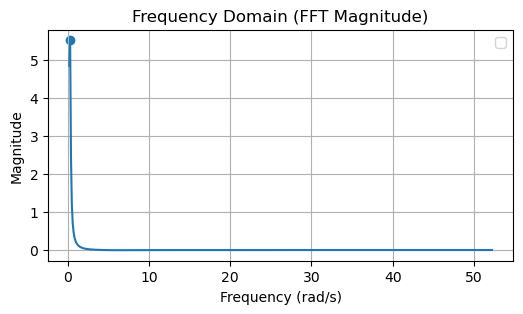

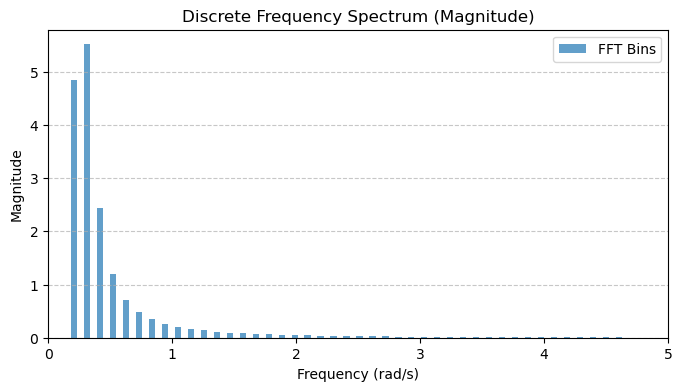

actual wn 0.31622776601683794


In [54]:
def get_frf(yexact2, times, force):
    N = len(yexact2)
    dt = times[1] - times[0]  # Sampling interval
    print(dt)
    yf = np.fft.fft(yexact2)
    ff = np.fft.fft(force)

    hf = yf/ff
    xf = np.fft.fftfreq(N, dt)[:N//2] # Get positive frequencies
   # print(f"xf: {xf}")
    #print(f"yf: {yf}")
    #print(f"ff: {ff}")
    #print(f"hf: {hf}")

    # 2. Get Magnitude (Power Spectrum)
    magnitude = 2.0/N * np.abs(hf[0:N//2])
    

    # 2. Get Magnitude (Power Spectrum)
    magnitude_trimmed = magnitude[2:]
    print(f"magnitude: {magnitude_trimmed}")
    xf_trimmed = xf[2:]

   
    


    return xf_trimmed, magnitude_trimmed

xf, magnitude = get_frf(yexact2, times, force_u2)
print(len(xf))
print(len(magnitude))

# 3. Find the peak frequency (Experimental wd) 
peak_index = np.argmax(magnitude)
print(peak_index)
wd_experimental = xf[peak_index] * 2 * np.pi # Convert Hz to rad/s
print(f"Experimental Damped Frequency (wd): {wd_experimental} rad/s")

xf_rad = 2* np.pi * xf


plt.figure(figsize=(6,3))
plt.plot(xf * 2 * np.pi, magnitude)
#plt.axvline(wd_experimental, color='r', linestyle='--', label=f'Peak at {wd_experimental:.2f} rad/s')
plt.scatter(wd_experimental, magnitude[peak_index])
plt.title("Frequency Domain (FFT Magnitude)")
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))

# Using bar to show the 'bins'
plt.bar(xf * 2 * np.pi, magnitude, width=0.05, color='tab:blue', alpha=0.7, label='FFT Bins')

# Optional: Add a stem plot on top for clarity
#plt.stem(xf * 2 * np.pi, magnitude, linefmt='r-', markerfmt='ro', basefmt=" ", label='Discrete Frequencies')

plt.title("Discrete Frequency Spectrum (Magnitude)")
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Magnitude")
plt.xlim(0, 5) # Zooming in on the area of interest (near omega0=20)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"actual wn {omega0_val}")

get metrics for wn, zeta, k,c

Fit Results: wn=0.30, zeta=0.24, Gain=2.95
Approximated wn: 0.29576857494578207 rad/s
actual wn: 0.31622776601683794 rad/s
Approximated zeta: 0.24451292122523988
actual zeta: 0.23717082451262844
Calculated Parameters: k=0.0874790499254587, c=0.14463847653323894
Actual Parameters: k=0.1, c=0.15, m=2
Percent error wn=6.469764286911636, zeta=3.0956997884115784
Percent error k=12.520950074541307, c=3.5743489778407023


/Users/abhi/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


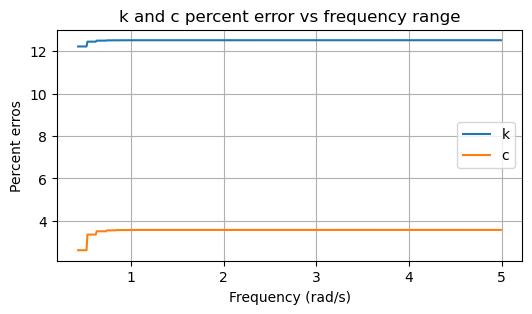

In [55]:
mask = (xf_rad > 0) & (xf_rad < 5) # only choosing frequencies between 0 and 5 where the max response magnitude is


w_data = xf_rad[mask]
mag_data = magnitude[mask]
#print(w_data)
#print(mag_data)




# Example of how to run the fit:
# p0: Initial guesses [wn, zeta, A]
# bounds: (lower_limits, upper_limits) 
# This prevents wn and zeta from going negative or zero
weights = mag_data

popt, pcov = curve_fit(
    response_magnitude, 
    w_data, 
    mag_data, 
    p0=[0.22, 0.19, 1.0], 
    bounds=((0.001, 0.001, 0.001), (np.inf, np.inf, np.inf)), sigma=1/weights
)


wn_fit, zeta_fit, A_fit = popt
print(f"Fit Results: wn={wn_fit:.2f}, zeta={zeta_fit:.2f}, Gain={A_fit:.2f}")

#wn_fit, zeta_fit = popt

zeta_actual = delta_val / omega0_val
wn_actual = omega0_val
print(f"Approximated wn: {wn_fit} rad/s")
print(f"actual wn: {wn_actual} rad/s")
print(f"Approximated zeta: {zeta_fit}")
print(f"actual zeta: {zeta_actual}")

m_est = 1.0
k_est = m_est * (wn_fit**2) #really finding k/m
k_actual = m_est * (wn_actual**2)
c_est = 2 * zeta_fit * wn_fit * m_est #really finding c/m
c_actual = 2 * zeta_actual * wn_actual * m_est

print(f"Calculated Parameters: k={k_est}, c={c_est}")
print(f"Actual Parameters: k={k_actual}, c={c_actual}, m={m_true}")

wn_percent_error_nff_nn_ns = abs(wn_fit - wn_actual) / wn_actual * 100
zeta_percent_error_nff_nn_ns = abs(zeta_fit - zeta_actual) / zeta_actual * 100

k_percent_error_nff_nn_ns = abs(k_est - k_actual) / k_actual * 100
c_percent_error_nff_nn_ns = abs(c_est - c_actual) / c_actual * 100

print(f"Percent error wn={wn_percent_error_nff_nn_ns}, zeta={zeta_percent_error_nff_nn_ns}")
print(f"Percent error k={k_percent_error_nff_nn_ns}, c={c_percent_error_nff_nn_ns}")

k_percent_errors = []
c_percent_error = []
frequency_range = np.arange(0.43, 5, 0.01).tolist()
#print(frequency_range)

for i in range(0,len(frequency_range)):
    mask = (xf_rad > 0) & (xf_rad < frequency_range[i]) # only choosing frequencies between 0 and 5 where the max response magnitude is


    w_data = xf_rad[mask]
    mag_data = magnitude[mask]
    
    weights = mag_data

    popt, pcov = curve_fit(
    response_magnitude, 
    w_data, 
    mag_data, 
    p0=[0.22, 0.19, 1.0], 
    bounds=((0.001, 0.001, 0.001), (np.inf, np.inf, np.inf)), sigma=1/weights
)


    wn_fit, zeta_fit, A_fit = popt
    zeta_actual = delta_val / omega0_val
    wn_actual = omega0_val

    m_est = 1.0
    k_est = m_est * (wn_fit**2) #really finding k/m
    k_actual = m_est * (wn_actual**2)
    c_est = 2 * zeta_fit * wn_fit * m_est #really finding c/m
    c_actual = 2 * zeta_actual * wn_actual * m_est

    wn_percent_error_nff_nn_ns = abs(wn_fit - wn_actual) / wn_actual * 100
    zeta_percent_error_nff_nn_ns = abs(zeta_fit - zeta_actual) / zeta_actual * 100

    k_percent_error_nff_nn_ns = abs(k_est - k_actual) / k_actual * 100
    c_percent_error_nff_nn_ns = abs(c_est - c_actual) / c_actual * 100

    k_percent_errors.append(k_percent_error_nff_nn_ns)
    c_percent_error.append(c_percent_error_nff_nn_ns)

plt.figure(figsize=(6,3))
plt.plot(frequency_range, k_percent_errors, label="k")
plt.plot(frequency_range, c_percent_error, label = "c")

plt.title("k and c percent error vs frequency range")
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Percent erros")
plt.legend()
plt.grid(True)
plt.show()





    

    

metrics for Square wave force

dict_keys(['t', 'x', 'v'])


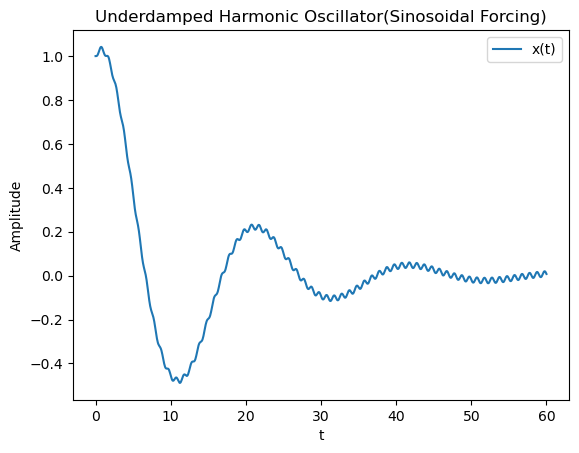

[array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(-1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(1.), array(-1.), array(-1.), array(-1.), array

No handles with labels found to put in legend.



1000
1000
0.06006006006006006
498
498
0
Experimental Damped Frequency (wd): 0.20923007072908023 rad/s


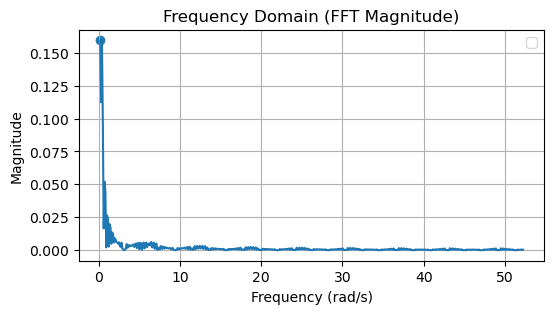

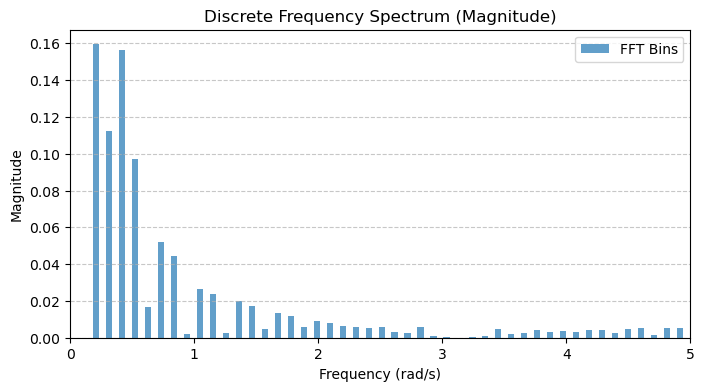

actual wn 0.31622776601683794
Fit Results: wn=0.41, zeta=0.48, Gain=0.12
Approximated wn: 0.4072923989276115 rad/s
actual wn: 0.31622776601683794 rad/s
Approximated zeta: 0.47672882804910527
actual zeta: 0.23717082451262844
Calculated Parameters: k=0.1658870982242086, c=0.38833605602813775
Actual Parameters: k=0.1, c=0.15, m=2
Percent error wn=28.797165428517335, zeta=101.00652305305844
Percent error k=65.8870982242086, c=158.8907040187585


/Users/abhi/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


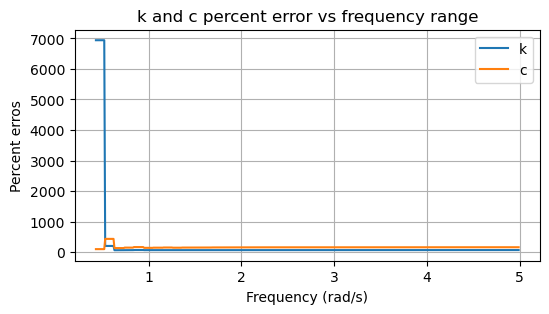

In [56]:
square_force_model = ground_truth_data['model: square wave force']


print(square_force_model.keys())


u_3 = lambda t: scipy.signal.square(2 * np.pi * 0.5 * t)
t = sinusoidal_force_model['t']
x = sinusoidal_force_model['x']
v = sinusoidal_force_model['v']

times = t
yexact2 = x

#plot our time displacement response
plt.plot(times, yexact2,label="x(t)")
plt.xlabel("t")
plt.ylabel("Amplitude")
plt.title("Underdamped Harmonic Oscillator(Sinosoidal Forcing)")
plt.legend()
plt.show()

force_u3 = []
for t in times:
    force_u3.append(u_3(t))

print(force_u3)
print(len(force_u3))
print(len(yexact2))


def get_frf(yexact2, times, force):
    N = len(yexact2)
    dt = times[1] - times[0]  # Sampling interval
    print(dt)
    yf = np.fft.fft(yexact2)
    ff = np.fft.fft(force)

    hf = yf/ff
    xf = np.fft.fftfreq(N, dt)[:N//2] # Get positive frequencies
   # print(f"xf: {xf}")
    #print(f"yf: {yf}")
    #print(f"ff: {ff}")
    #print(f"hf: {hf}")

    # 2. Get Magnitude (Power Spectrum)
    magnitude = 2.0/N * np.abs(hf[0:N//2])
    

    # 2. Get Magnitude (Power Spectrum)
    magnitude_trimmed = magnitude[2:]
   # print(f"magnitude: {magnitude_trimmed}")
    xf_trimmed = xf[2:]

   
    


    return xf_trimmed, magnitude_trimmed

xf, magnitude = get_frf(yexact2, times, force_u3)
magnitude[~np.isfinite(magnitude)] = 0
print(len(xf))
print(len(magnitude))

# 3. Find the peak frequency (Experimental wd) 
peak_index = np.argmax(magnitude)
print(peak_index)
wd_experimental = xf[peak_index] * 2 * np.pi # Convert Hz to rad/s
print(f"Experimental Damped Frequency (wd): {wd_experimental} rad/s")

xf_rad = 2* np.pi * xf


plt.figure(figsize=(6,3))
plt.plot(xf * 2 * np.pi, magnitude)
#plt.axvline(wd_experimental, color='r', linestyle='--', label=f'Peak at {wd_experimental:.2f} rad/s')
plt.scatter(wd_experimental, magnitude[peak_index])
plt.title("Frequency Domain (FFT Magnitude)")
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))

# Using bar to show the 'bins'
plt.bar(xf * 2 * np.pi, magnitude, width=0.05, color='tab:blue', alpha=0.7, label='FFT Bins')

# Optional: Add a stem plot on top for clarity
#plt.stem(xf * 2 * np.pi, magnitude, linefmt='r-', markerfmt='ro', basefmt=" ", label='Discrete Frequencies')

plt.title("Discrete Frequency Spectrum (Magnitude)")
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Magnitude")
plt.xlim(0, 5) # Zooming in on the area of interest (near omega0=20)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"actual wn {omega0_val}")

mask = (xf_rad > 0) & (xf_rad < 5) # only choosing frequencies between 0 and 5 where the max response magnitude is


w_data = xf_rad[mask]
mag_data = magnitude[mask]
#print(w_data)
#print(mag_data)




# Example of how to run the fit:
# p0: Initial guesses [wn, zeta, A]
# bounds: (lower_limits, upper_limits) 
# This prevents wn and zeta from going negative or zero
popt, pcov = curve_fit(
    response_magnitude, 
    w_data, 
    mag_data, 
    p0=[0.22, 0.19, 1.0], 
    bounds=((0.001, 0.001, 0.001), (np.inf, np.inf, np.inf))
)

wn_fit, zeta_fit, A_fit = popt
print(f"Fit Results: wn={wn_fit:.2f}, zeta={zeta_fit:.2f}, Gain={A_fit:.2f}")

#wn_fit, zeta_fit = popt

zeta_actual = delta_val / omega0_val
wn_actual = omega0_val
print(f"Approximated wn: {wn_fit} rad/s")
print(f"actual wn: {wn_actual} rad/s")
print(f"Approximated zeta: {zeta_fit}")
print(f"actual zeta: {zeta_actual}")

m_est = 1.0
k_est = m_est * (wn_fit**2) #really finding k/m
k_actual = m_est * (wn_actual**2)
c_est = 2 * zeta_fit * wn_fit * m_est #really finding c/m
c_actual = 2 * zeta_actual * wn_actual * m_est

print(f"Calculated Parameters: k={k_est}, c={c_est}")
print(f"Actual Parameters: k={k_actual}, c={c_actual}, m={m_true}")

wn_percent_error_nff_nn_ns = abs(wn_fit - wn_actual) / wn_actual * 100
zeta_percent_error_nff_nn_ns = abs(zeta_fit - zeta_actual) / zeta_actual * 100

k_percent_error_nff_nn_ns = abs(k_est - k_actual) / k_actual * 100
c_percent_error_nff_nn_ns = abs(c_est - c_actual) / c_actual * 100

print(f"Percent error wn={wn_percent_error_nff_nn_ns}, zeta={zeta_percent_error_nff_nn_ns}")
print(f"Percent error k={k_percent_error_nff_nn_ns}, c={c_percent_error_nff_nn_ns}")

k_percent_errors = []
c_percent_error = []
frequency_range = np.arange(0.43, 5, 0.01).tolist()
#print(frequency_range)

for i in range(0,len(frequency_range)):
    mask = (xf_rad > 0) & (xf_rad < frequency_range[i]) # only choosing frequencies between 0 and 5 where the max response magnitude is


    w_data = xf_rad[mask]
    mag_data = magnitude[mask]
    
    popt, pcov = curve_fit(
    response_magnitude, 
    w_data, 
    mag_data, 
    p0=[0.22, 0.19, 1.0], 
    bounds=((0.001, 0.001, 0.001), (np.inf, np.inf, np.inf))
)

    wn_fit, zeta_fit, A_fit = popt
    zeta_actual = delta_val / omega0_val
    wn_actual = omega0_val

    m_est = 1.0
    k_est = m_est * (wn_fit**2) #really finding k/m
    k_actual = m_est * (wn_actual**2)
    c_est = 2 * zeta_fit * wn_fit * m_est #really finding c/m
    c_actual = 2 * zeta_actual * wn_actual * m_est

    wn_percent_error_nff_nn_ns = abs(wn_fit - wn_actual) / wn_actual * 100
    zeta_percent_error_nff_nn_ns = abs(zeta_fit - zeta_actual) / zeta_actual * 100

    k_percent_error_nff_nn_ns = abs(k_est - k_actual) / k_actual * 100
    c_percent_error_nff_nn_ns = abs(c_est - c_actual) / c_actual * 100

    k_percent_errors.append(k_percent_error_nff_nn_ns)
    c_percent_error.append(c_percent_error_nff_nn_ns)

plt.figure(figsize=(6,3))
plt.plot(frequency_range, k_percent_errors, label="k")
plt.plot(frequency_range, c_percent_error, label = "c")

plt.title("k and c percent error vs frequency range")
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Percent erros")
plt.legend()
plt.grid(True)
plt.show()





    

    


